In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

In [70]:
RANDOM_SEED = 42

## Load datasets

In [71]:
transactions_df = pd.read_csv("../data/raw/transactions_data.csv", parse_dates=["date"])
target_labels_df = pd.read_json("../data/raw/train_fraud_labels.json")

In [72]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              int64         
 1   date            datetime64[ns]
 2   client_id       int64         
 3   card_id         int64         
 4   amount          object        
 5   use_chip        object        
 6   merchant_id     int64         
 7   merchant_city   object        
 8   merchant_state  object        
 9   zip             float64       
 10  mcc             int64         
 11  errors          object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(5)
memory usage: 1.2+ GB


### Initial preprocessing

In [73]:
transactions_df = transactions_df.astype({n:str(transactions_df[n].dtype).replace("64", "32") for n in transactions_df.select_dtypes(include=["int64", "float64"]).columns})

In [74]:
transactions_df["amount"] = transactions_df["amount"].str.replace("$","").astype(float)

In [75]:
print("Shape Transactions:",transactions_df.shape)
print("Columns Transactions:",transactions_df.columns)
print("Shape Labels:",target_labels_df.shape)
print("Columns Labels:",target_labels_df.columns)

Shape Transactions: (13305915, 12)
Columns Transactions: Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors'],
      dtype='object')
Shape Labels: (8914963, 1)
Columns Labels: Index(['target'], dtype='object')


## Merge with target labels

In [76]:
with_labels = transactions_df[transactions_df.id.isin(target_labels_df.index)]
no_labels = transactions_df[~(transactions_df.id.isin(target_labels_df.index))]
print("With labels:", with_labels.shape)
print("No labels:", no_labels.shape)

With labels: (8914963, 12)
No labels: (4390952, 12)


No labels records are intended for the submission file (test)

In [77]:
no_labels.to_csv("../data/raw/test_transactions.csv")

In [78]:
# the rest will be 
print("Transactions wit labels before merging",len(with_labels["id"].unique()))
transactions_df = with_labels.merge(target_labels_df.reset_index().rename(columns={"index":"id", "target":"target"}), on="id")
print("Transactions after merging",len(transactions_df["id"].unique()))



Transactions wit labels before merging 8914963
Transactions after merging 8914963


## Explore Nan records

In [81]:
nan_records=transactions_df.isna().sum()
fraction = nan_records/transactions_df.shape[0]
pd.concat([nan_records, fraction], axis = 1).rename({"0":"Number of records", "1":"Fraction of total"})

,0,1
id,0,0.000000
date,0,0.000000
client_id,0,0.000000
card_id,0,0.000000
amount,0,0.000000
use_chip,0,0.000000
merchant_id,0,0.000000
merchant_city,0,0.000000
merchant_state,1047865,0.117540
zip,1107377,0.124216


In [82]:
records_with_empty_state = transactions_df[transactions_df.merchant_state.isna()]
records_with_empty_zip = transactions_df[transactions_df.zip.isna()]
records_with_empty_errors = transactions_df[transactions_df.errors.isna()]

<Axes: title={'center': 'errors'}, xlabel='target', ylabel='count'>

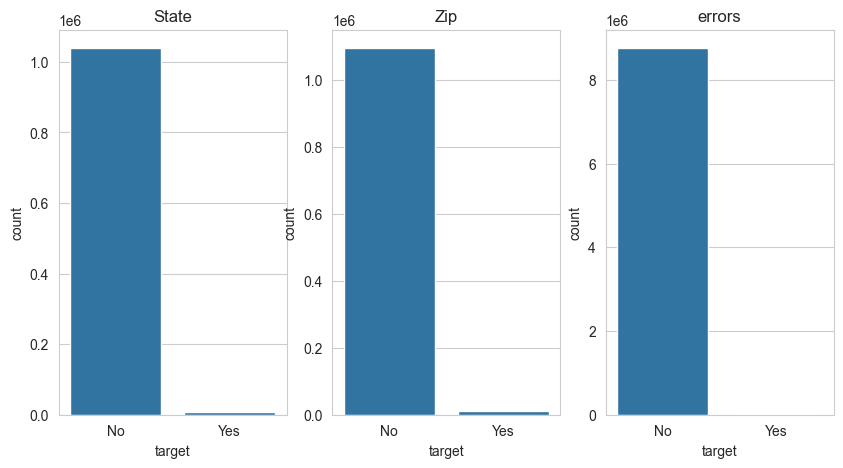

In [ ]:
# target distribution
fig, axes = plt.subplots(1,3, figsize=(10,5))
axes[0].set_title("State")
sns.countplot(data=records_with_empty_state, x = "target", ax=axes[0])
axes[1].set_title("Zip")
sns.countplot(data=records_with_empty_zip, x = "target", ax=axes[1])
axes[2].set_title("Errors")
sns.countplot(data=records_with_empty_errors, x = "target", ax=axes[2])


In [ ]:
city_count_state_nan = records_with_empty_state.merchant_city.value_counts().rename("State Nan")
city_count_zip_nan = records_with_empty_zip.merchant_city.value_counts().rename("Zip Nan")
all_cities = transactions_df["merchant_city"].value_counts().rename("Total")
pd.concat([all_cities, city_count_state_nan, city_count_zip_nan], axis = 1).dropna(axis=0, subset=["State Nan", "Zip Nan"], how="all")

,Total,State Nan,Zip Nan
merchant_city,,,
ONLINE,1047865,1047865.0,1047865.0
San Jose,20411,NaN,462.0
Vancouver,10388,NaN,1455.0
Panama City,8158,NaN,11.0
Warsaw,7256,NaN,154.0
...,...,...,...
Honiara,2,NaN,2.0
Malabo,2,NaN,2.0
Nuku Alofa,1,NaN,1.0


Missing city -> Online purchase

In [ ]:
tea